#Creating Cohorts of Songs.

**Problem Scenario:**

The customer always looks forward to specialized treatment, whether shopping on an e-commerce website or watching Netflix. The customer desires content that aligns with their preferences. To maintain customer engagement, companies must consistently provide the most relevant information.

Starting with Spotify, a Swedish audio streaming and media service provider, boasts over 456 million active monthly users, including more than 195 million paid subscribers as of September 2022. The company aims to create cohorts of different songs to enhance song recommendations. These cohorts will be based on various relevant features, ensuring that each group contains similar types of songs.

**Problem Objective:**

As a data scientist, you should perform exploratory data analysis and cluster analysis to create cohorts of songs. The goal is to better understand the various factors that create a cohort of songs.

**Data Description:**

The dataset comprises information from Spotify's API regarding all albums by the Rolling Stones available on Spotify. It's crucial to highlight that each song possesses a unique ID.

## Importing Required Libraries

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [53]:
#Loading Dataset
file_path = 'https://raw.githubusercontent.com/udaybhaskar-git/Datasets/refs/heads/main/rolling_stones_spotify.csv' #dataset imported from public github repo
song_data_orig=pd.read_csv(file_path)
song_data=song_data_orig.copy() #Keeping the original copy of the dataset import
song_data.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


## Step1: Data Inspection and Data Cleaning

In [54]:
song_data.describe()

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


In [55]:
song_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


In [56]:
# Drop irrelevant index column,
song_data.drop(columns=["Unnamed: 0"], inplace=True)

In [57]:
# Check for missing values
song_data.isnull().sum()

,0
name,0
album,0
release_date,0
track_number,0
id,0
uri,0
acousticness,0
danceability,0
energy,0
instrumentalness,0


In [58]:
# Check for duplicates
song_data.duplicated().sum()

np.int64(0)

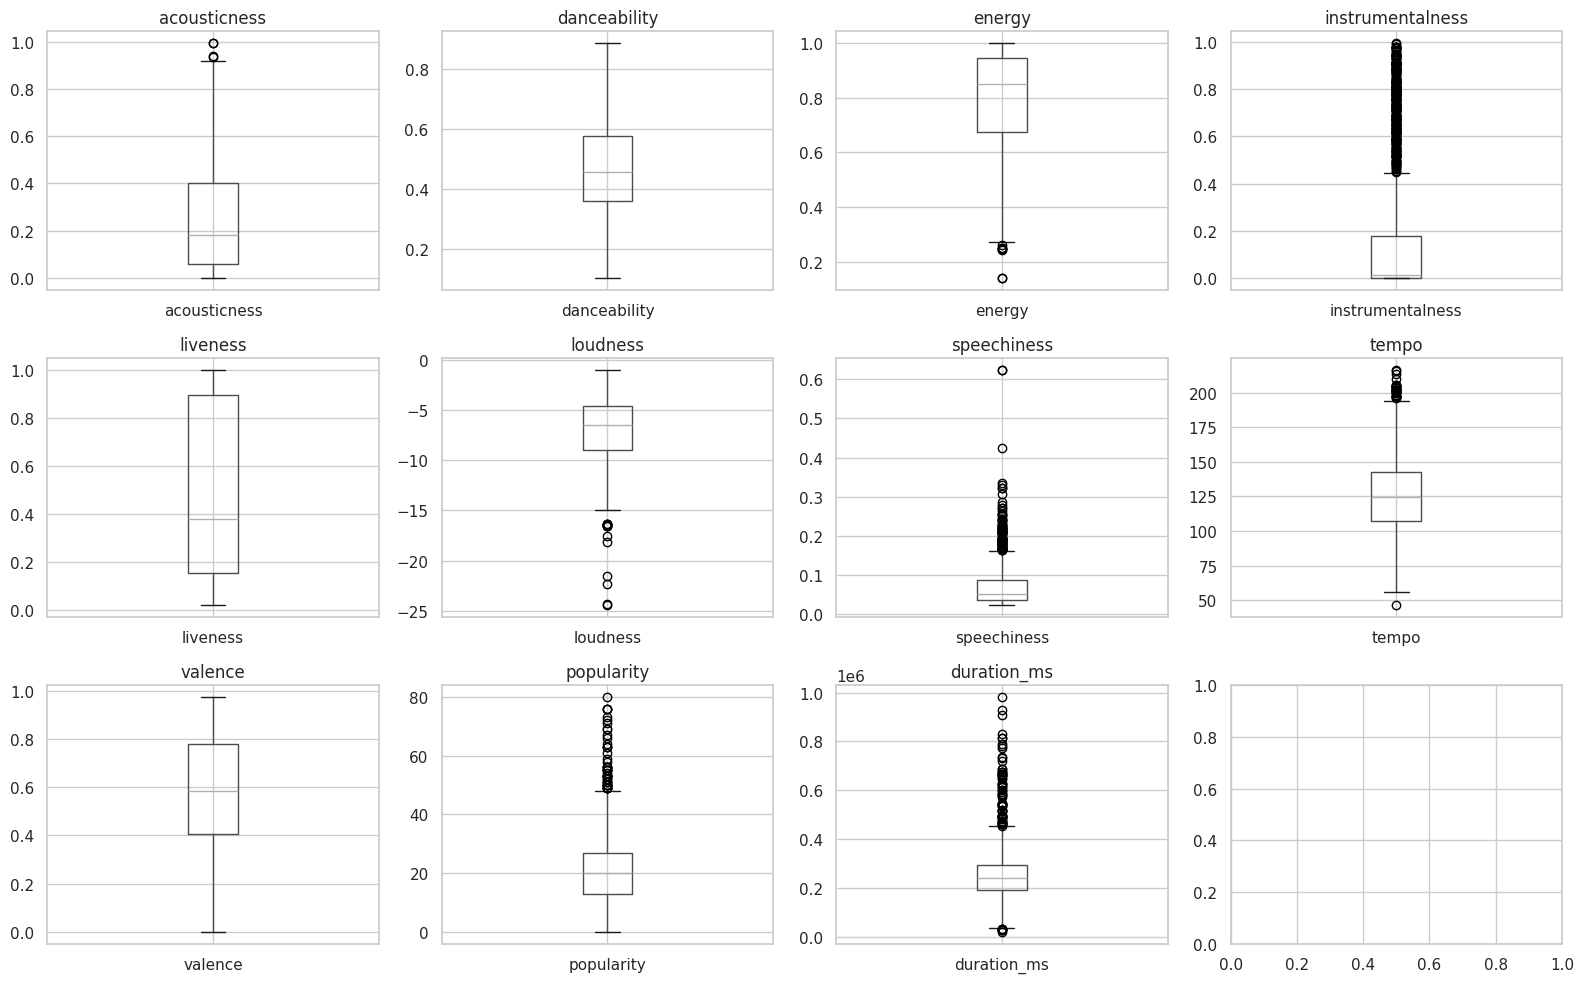

In [59]:
# Boxplots to detect outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
numeric_cols = ["acousticness", "danceability", "energy", "instrumentalness",
                "liveness", "loudness", "speechiness", "tempo", "valence",
                "popularity", "duration_ms"]
for ax, col in zip(axes.flatten(), numeric_cols):
    song_data.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [60]:
song_data.describe()

,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


In [61]:
song_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1610 non-null   object 
 1   album             1610 non-null   object 
 2   release_date      1610 non-null   object 
 3   track_number      1610 non-null   int64  
 4   id                1610 non-null   object 
 5   uri               1610 non-null   object 
 6   acousticness      1610 non-null   float64
 7   danceability      1610 non-null   float64
 8   energy            1610 non-null   float64
 9   instrumentalness  1610 non-null   float64
 10  liveness          1610 non-null   float64
 11  loudness          1610 non-null   float64
 12  speechiness       1610 non-null   float64
 13  tempo             1610 non-null   float64
 14  valence           1610 non-null   float64
 15  popularity        1610 non-null   int64  
 16  duration_ms       1610 non-null   int64  


Outliers?
Erraneous entries ?


### Observation/Thoughts:

The dataset contains 1,610 songs across 90 albums spanning 1964–2022. All 18 columns are complete with zero missing values. 17 songs have a popularity of 0 (mostly live recordings), and 102 (name, album) combinations repeat, likely due to remastered editions sharing identical metadata except for release date. Since each song has a unique Spotify ID, these are retained as distinct entries.

The data Looks clean
 - no missing values
 - no duplicates
 - feature distributions appear logical and meaningful for analysis.
 -  17 songs have popularity = 0 — mostly live recordings.
 - 257 songs have instrumentalness > 0.5 (instrumental tracks).
 - loudness ranges from –24.4 dB to –1.0 dB — no extreme outliers.

## Step 2: Data Refinement

Goals:

- Drop non-numeric columns for clustering
- Convert release_date to datetime
- Keep name, album, release_date for EDA (not clustering)
- Normalize features for clustering

In [62]:
# Convert release_date to datetime
song_data["release_date"] = pd.to_datetime(song_data["release_date"], errors='coerce')

# Store metadata separately for visualization
song_data_metadata = song_data[["name", "album", "release_date"]]
song_data_metadata["release_year"] = song_data["release_date"].dt.year
song_data["release_year"] = song_data["release_date"].dt.year

# Drop non-music feature columns
cluster_features = ["acousticness", "danceability", "energy", "instrumentalness",
                    "liveness", "loudness", "speechiness", "tempo", "valence"]
song_data_model = song_data[cluster_features]

# Normalize all features for clustering
scaler = StandardScaler()
song_data_scaled = pd.DataFrame(scaler.fit_transform(song_data_model), columns=song_data_model.columns)

# For time-based EDA, keep year
song_data_scaled["release_year"] = song_data["release_date"].dt.year

/tmp/ipykernel_13559/868393135.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  song_data_metadata["release_year"] = song_data["release_date"].dt.year


## Step 3: Exploratory Data Analysis (EDA) and Feature Engineering

### 3a: Identify Most Popular Albums for Recommendation

In [63]:
# Group by album and count songs with popularity > 50
popular_albums = song_data[song_data["popularity"] > 50].groupby("album")["popularity"].count().sort_values(ascending=False)

# Top 2 albums with highest number of popular songs
print("Top two Recommended Albums:\n", popular_albums.head(2))


Top two Recommended Albums:
 album
Sticky Fingers (Remastered)                6
Exile On Main Street (2010 Re-Mastered)    4
Name: popularity, dtype: int64


/tmp/ipykernel_13559/3831718211.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular_albums_all.values, y=popular_albums_all.index, palette="viridis")


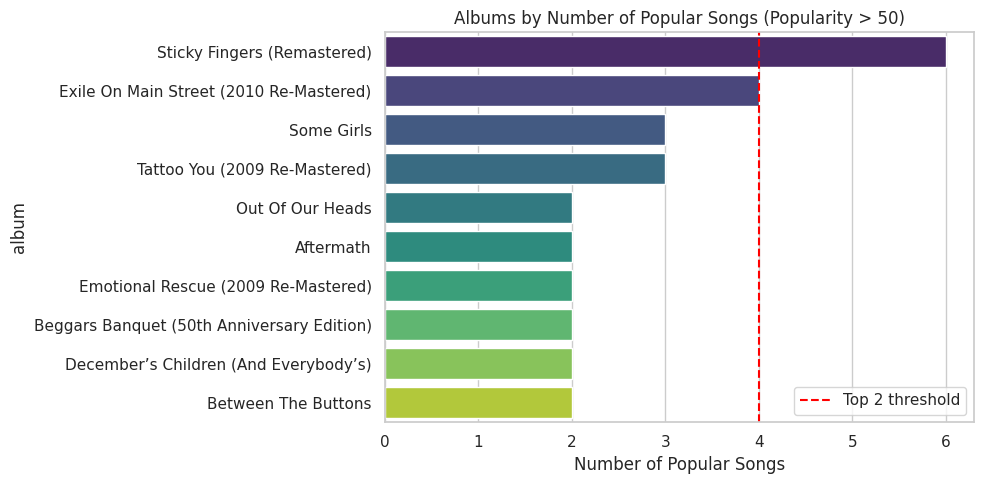

In [64]:
popular_albums_all = song_data[song_data["popularity"] > 50].groupby("album")["popularity"].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=popular_albums_all.values, y=popular_albums_all.index, palette="viridis")
plt.title("Albums by Number of Popular Songs (Popularity > 50)")
plt.xlabel("Number of Popular Songs")
plt.axvline(x=popular_albums_all.iloc[1], color='red', linestyle='--', label='Top 2 threshold')
plt.legend()
plt.tight_layout()
plt.show()

**Insights:**

Sticky Fingers (Remastered) leads with 6 songs having popularity > 50, followed by Exile on Main Street (2010 Re-Mastered) with 4. Notably, remastered albums dominate the top positions, suggesting that Spotify's popularity metric rewards catalog rediscovery through remastering.

###3b: Feature Distributions & Patterns

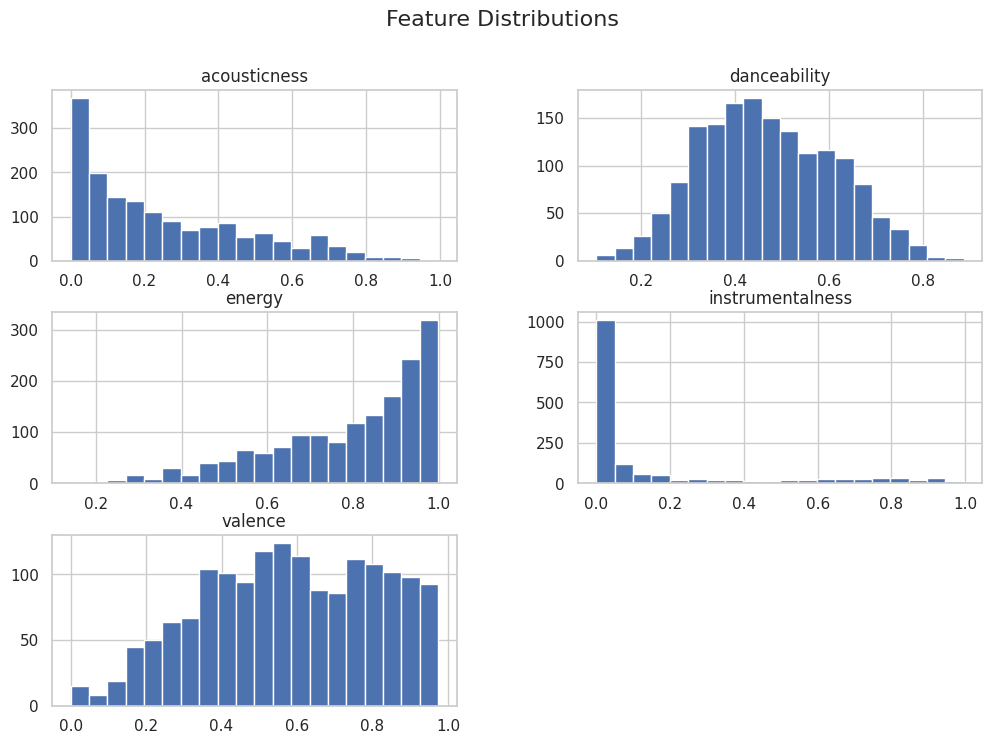

In [65]:
# Plot distributions of key audio features
features_to_plot = ["acousticness", "danceability", "energy", "instrumentalness", "valence"]
song_data[features_to_plot].hist(bins=20, figsize=(12, 8))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

**Insights:**

Acousticness is heavily right-skewed — the majority of RS songs score below 0.2, consistent with an electric rock band. Instrumentalness clusters near 0 for most tracks (vocal songs) with a secondary cluster near 1.0 (pure instrumentals). Danceability follows a near-normal distribution centered around 0.5.

### 3c: Correlation Between Popularity & Features

Correlation with Popularity:
 popularity          1.000000
loudness            0.156323
danceability        0.141205
acousticness        0.108046
duration_ms         0.074102
valence             0.065333
instrumentalness   -0.010612
energy             -0.057272
tempo              -0.061061
release_year       -0.081648
speechiness        -0.136745
track_number       -0.145115
liveness           -0.205845
Name: popularity, dtype: float64


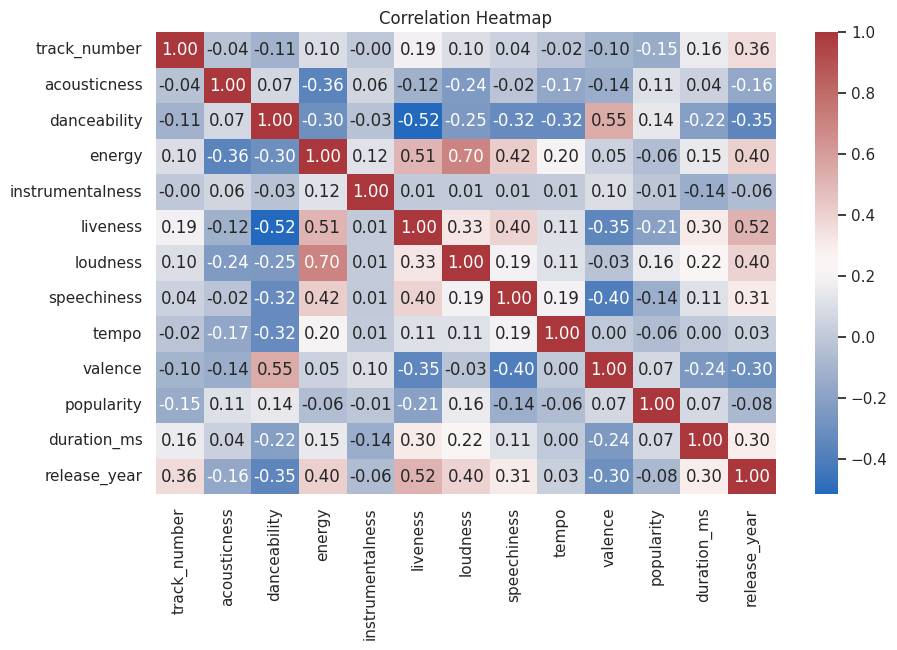

In [66]:
# Calculate correlation
correlation = song_data.corr(numeric_only=True)["popularity"].sort_values(ascending=False)
print("Correlation with Popularity:\n", correlation)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(song_data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag")
plt.title("Correlation Heatmap")
plt.show()


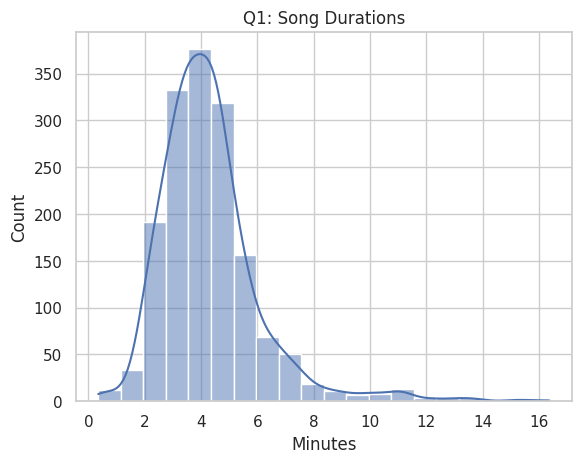

In [67]:

sns.set(style="whitegrid")

# Q1: Distribution of song durations
plt.figure()
sns.histplot(song_data["duration_ms"] / 60000, bins=20, kde=True)
plt.title("Q1: Song Durations")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

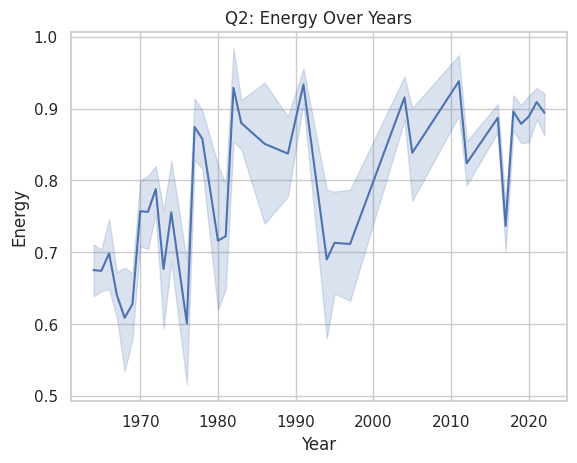

In [68]:
# Q2: Energy trend over years
plt.figure()
sns.lineplot(x="release_year", y="energy", data=song_data)
plt.title("Q2: Energy Over Years")
plt.xlabel("Year")
plt.ylabel("Energy")
plt.show()

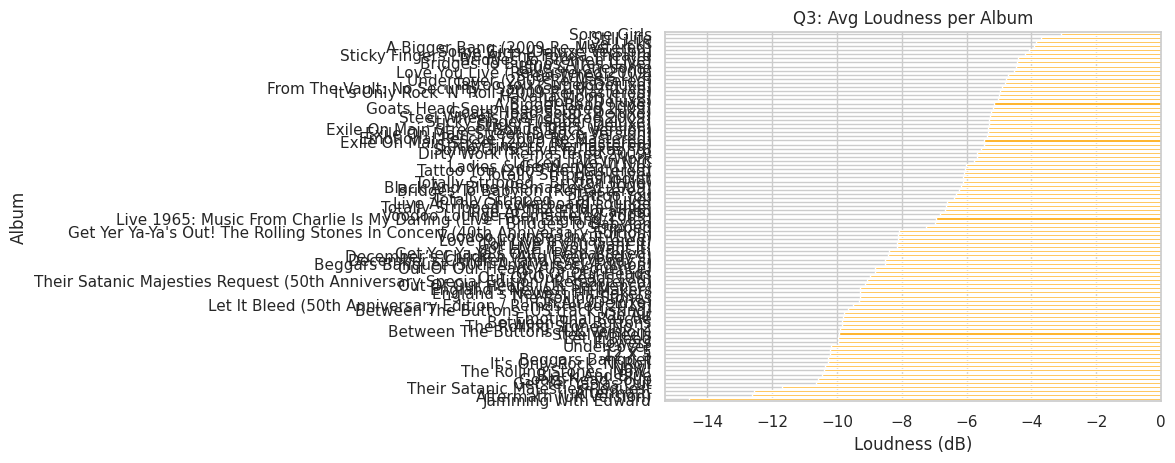

In [69]:
# Q3: Average loudness per album
avg_loudness = song_data.groupby("album")["loudness"].mean().sort_values()
plt.figure()
avg_loudness.plot(kind='barh', color='orange')
plt.title("Q3: Avg Loudness per Album")
plt.xlabel("Loudness (dB)")
plt.ylabel("Album")
plt.show()


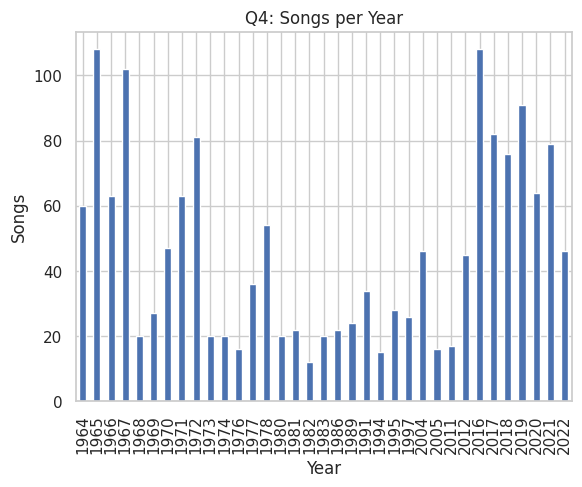

In [70]:
# Q4: Songs released per year
plt.figure(); song_data["release_year"].value_counts().sort_index().plot(kind='bar')
plt.title("Q4: Songs per Year")
plt.xlabel("Year")
plt.ylabel("Songs")
plt.show()

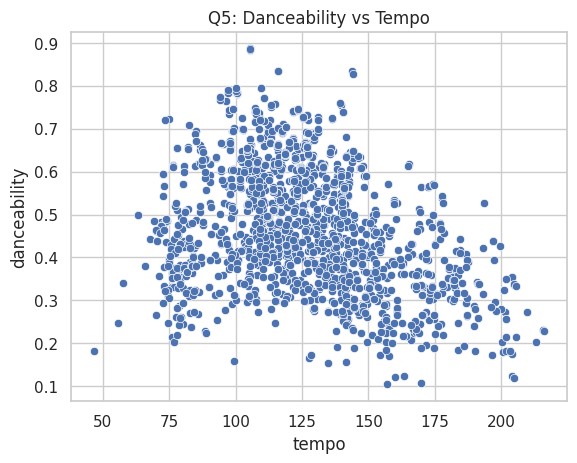

In [71]:

# Q5: Danceability vs Tempo
plt.figure()
sns.scatterplot(x="tempo", y="danceability", data=song_data)
plt.title("Q5: Danceability vs Tempo")
plt.show()

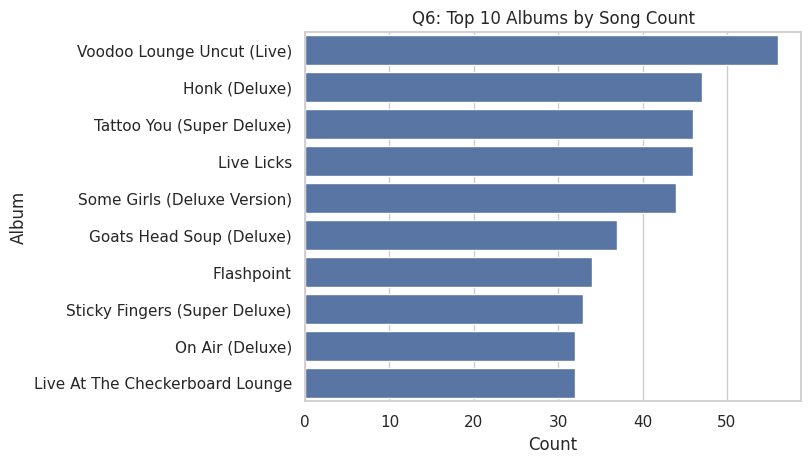

In [72]:

# Q6: Top 10 albums by number of songs
top_albums = song_data["album"].value_counts().head(10)
plt.figure()
sns.barplot(y=top_albums.index, x=top_albums.values)
plt.title("Q6: Top 10 Albums by Song Count")
plt.xlabel("Count")
plt.ylabel("Album")
plt.show()


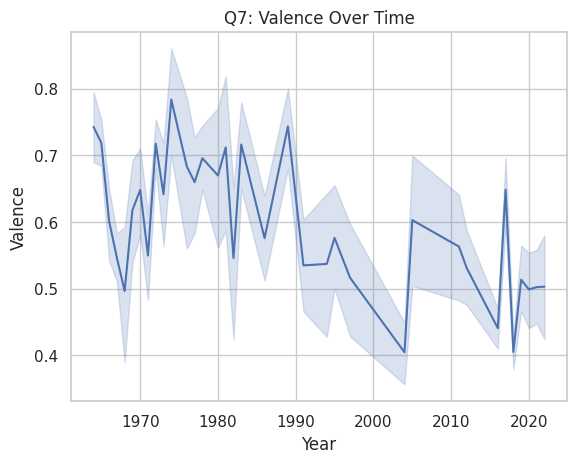

In [73]:

# Q7: Valence trend over years
plt.figure()
sns.lineplot(x="release_year", y="valence", data=song_data)
plt.title("Q7: Valence Over Time")
plt.xlabel("Year")
plt.ylabel("Valence")
plt.show()


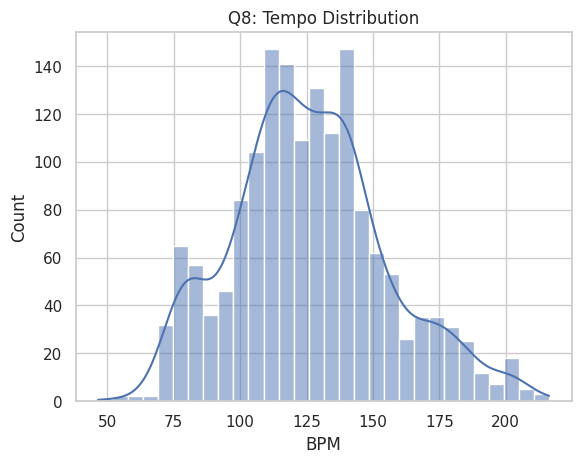

In [74]:
# Q8: Tempo distribution
plt.figure()
sns.histplot(song_data["tempo"], bins=30, kde=True)
plt.title("Q8: Tempo Distribution")
plt.xlabel("BPM")
plt.ylabel("Count")
plt.show()


In [75]:
# Q9: Loudest songs
loudest = song_data.sort_values("loudness", ascending=False)[["name", "loudness"]].head(10)
loudest

,name,loudness
58,Fiji Jim,-1.014
50,Black Limousine - Remastered 2021,-1.382
96,Black Limousine - Remastered 2021,-1.382
57,Living In The Heart Of Love,-1.392
929,Lies - Remastered,-1.568
897,Lies - Remastered,-1.568
907,Lies - Remastered,-1.568
51,Neighbours - Remastered 2021,-1.712
97,Neighbours - Remastered 2021,-1.712
93,Hang Fire - Remastered 2021,-1.734


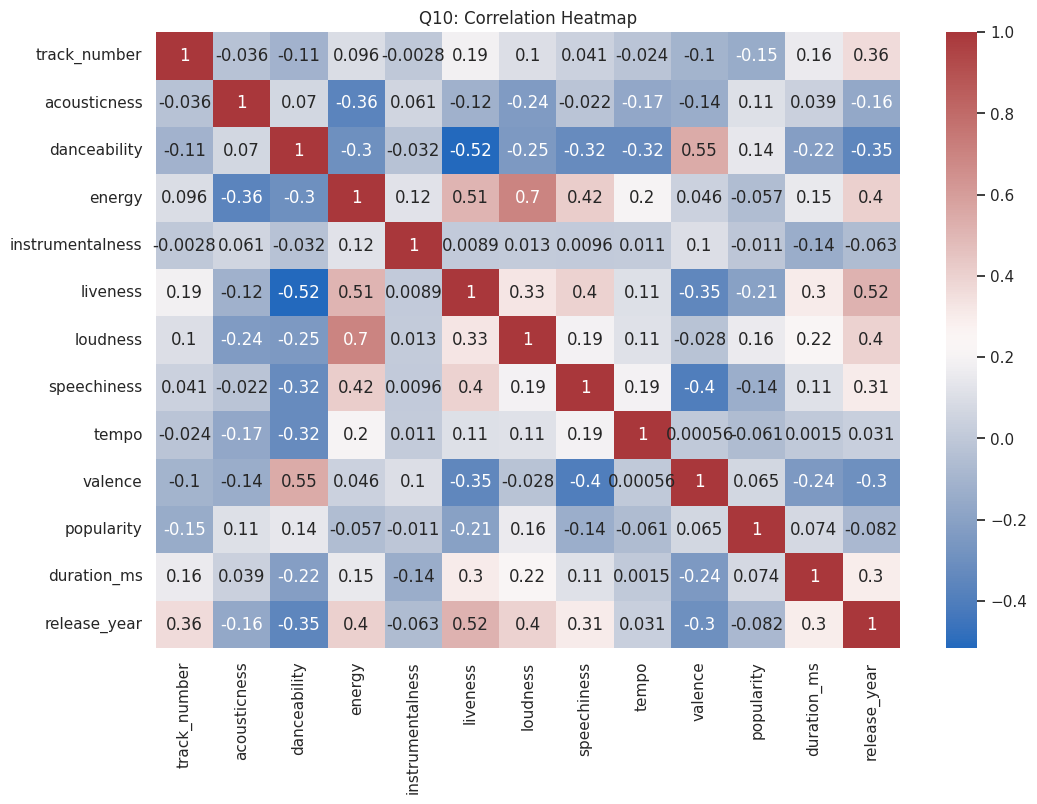

In [76]:
# Q10: Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(song_data.select_dtypes(include=np.number).corr(), annot=True, cmap="vlag")
plt.title("Q10: Correlation Heatmap")
plt.show()

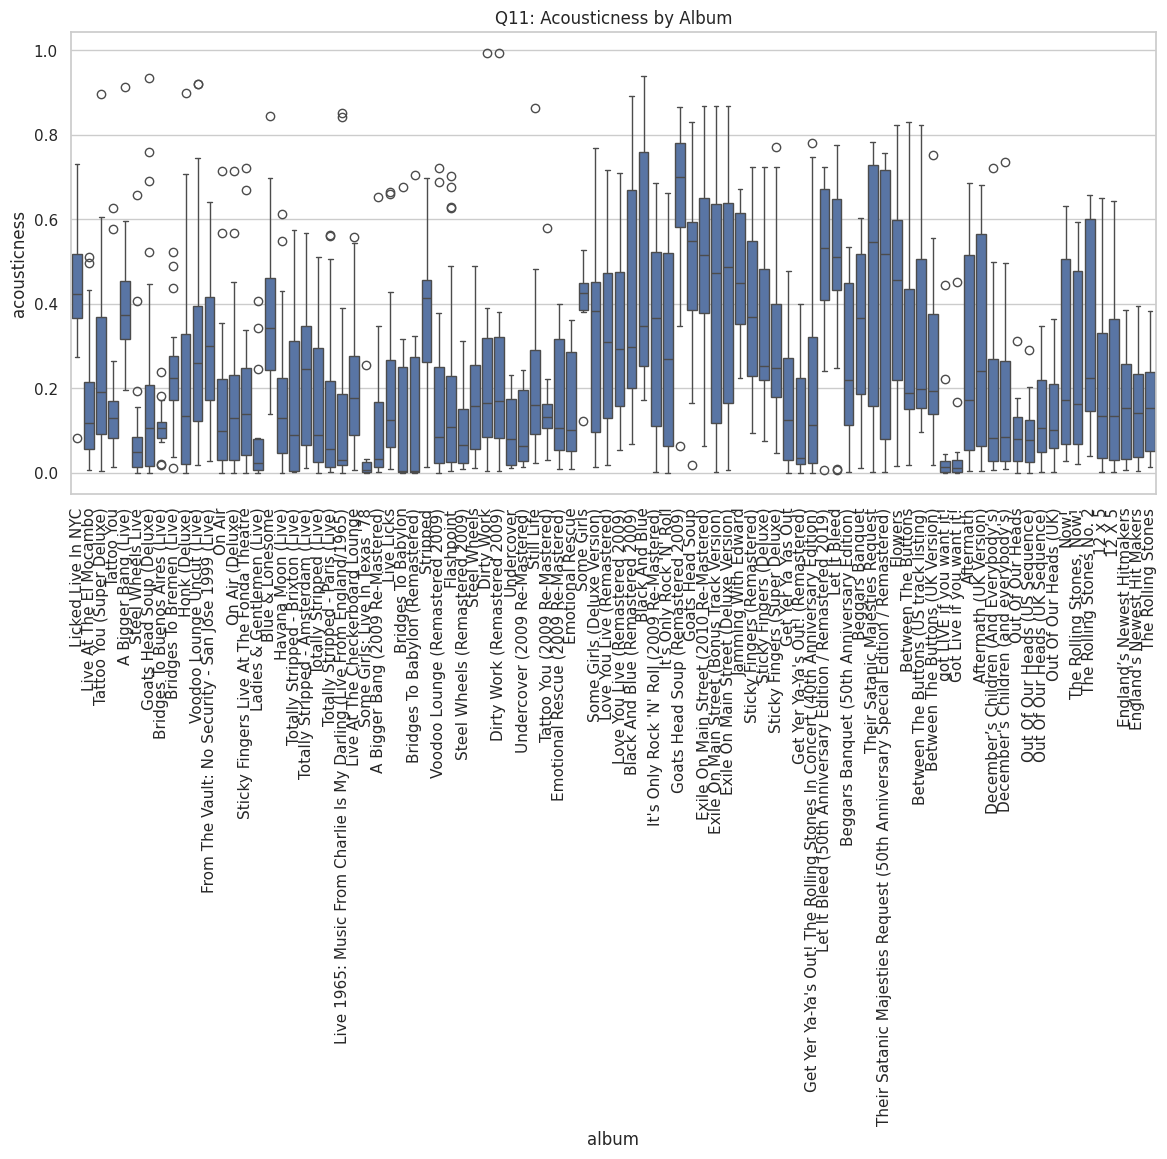

In [77]:
# Q11: Acousticness across albums
plt.figure(figsize=(14, 6))
sns.boxplot(x="album", y="acousticness", data=song_data)
plt.title("Q11: Acousticness by Album")
plt.xticks(rotation=90)
plt.show()

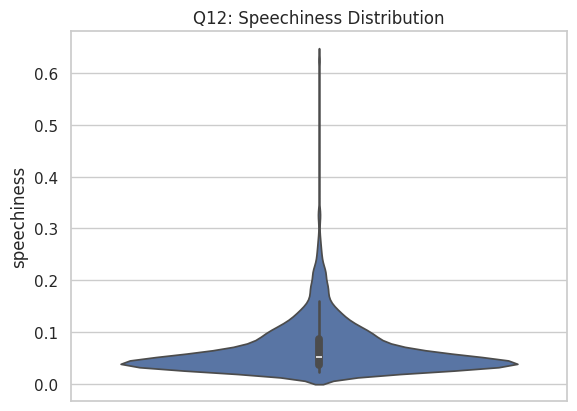

In [78]:
# Q12: Distribution of speechiness
plt.figure()
sns.violinplot(data=song_data, y="speechiness")
plt.title("Q12: Speechiness Distribution")
plt.show()

In [79]:
# Q13: Songs with high danceability
high_dance = song_data[song_data["danceability"] > 0.8][["name", "danceability"]]
high_dance

,name,danceability
924,Petrol Blues,0.835
946,Petrol Blues,0.835
985,Cherry Oh Baby - Remastered,0.835
993,Cherry Oh Baby,0.828
1580,I'm A King Bee,0.887
1592,I'm A King Bee,0.884
1604,I'm A King Bee,0.886


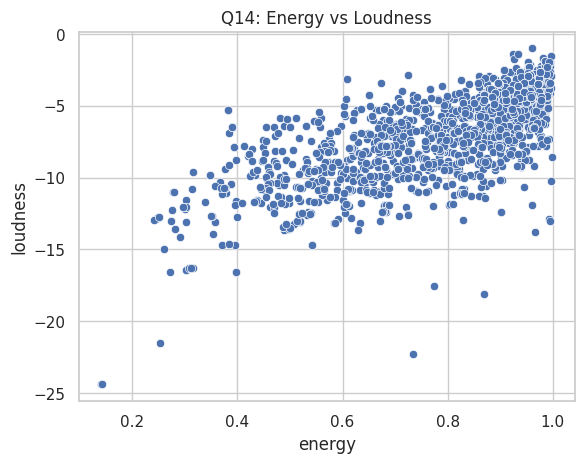

In [80]:
# Q14: Energy vs Loudness
plt.figure()
sns.scatterplot(data=song_data, x="energy", y="loudness")
plt.title("Q14: Energy vs Loudness")
plt.show()

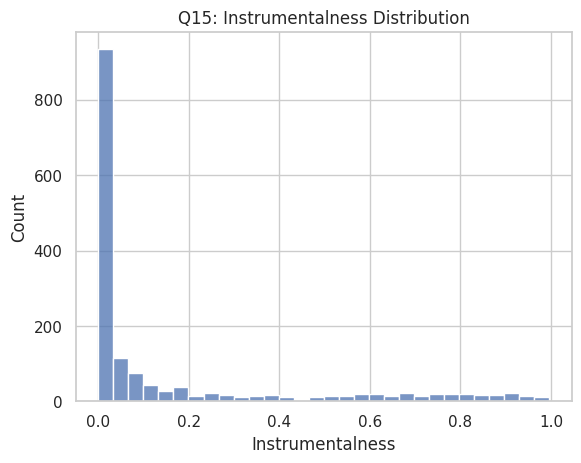

In [81]:
# Q15: Instrumentalness distribution
plt.figure()
sns.histplot(song_data["instrumentalness"], bins=30)
plt.title("Q15: Instrumentalness Distribution")
plt.xlabel("Instrumentalness")
plt.show()


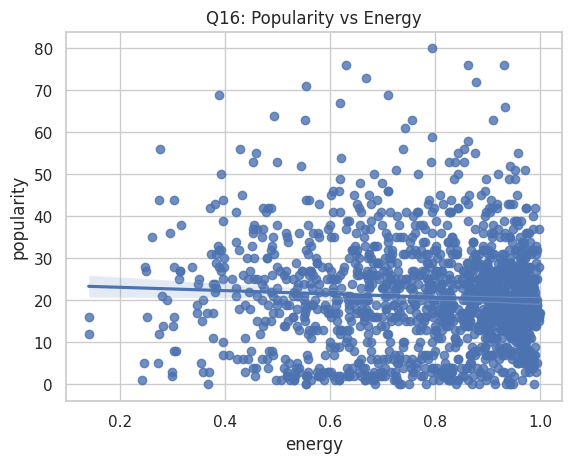

In [82]:
# Q16: Popularity vs Energy
plt.figure()
sns.regplot(data=song_data, x="energy", y="popularity")
plt.title("Q16: Popularity vs Energy")
plt.show()


In [83]:
# Q17: Most popular songs
top_popular = song_data.sort_values("popularity", ascending=False)[["name", "popularity"]].head(5)
top_popular



,name,popularity
1403,"Paint It, Black",80
1472,(I Can't Get No) Satisfaction - Mono Version,76
862,Start Me Up - Remastered 2009,76
1248,Gimme Shelter,76
1257,Sympathy For The Devil - 50th Anniversary Edition,73


In [84]:
# Q18: Least popular songs
least_popular = song_data.sort_values("popularity", ascending=False)[["name", "popularity"]].tail(20)
least_popular

,name,popularity
1339,Who's Been Sleeping Here?,1
1353,Miss Amanda Jones,1
1336,"Cool, Calm And Collected",1
1595,Can I Get A Witness,0
1397,The Last Time - Live,0
1590,Now I've Got A Witness,0
1597,Walking The Dog,0
1596,You Can Make It If You Try,0
1592,I'm A King Bee,0
587,Next Time You See Me - Live,0


In [85]:
# Q19: Longest songs
longest = song_data.sort_values("duration_ms", ascending=False)[["name", "duration_ms"]].head(10)
longest

,name,duration_ms
220,Miss You - Live,981866
460,Midnight Rambler - Live,929457
537,Miss You - Live,907373
482,Miss You - Live,831960
325,Miss You - Live,815887
297,Miss You - Live,815887
1175,Midnight Rambler - Live At University Of Leeds...,789240
8,Midnight Rambler - Live,781173
183,Midnight Rambler - Live / Forest National Aren...,773226
111,Midnight Rambler - Live,734706


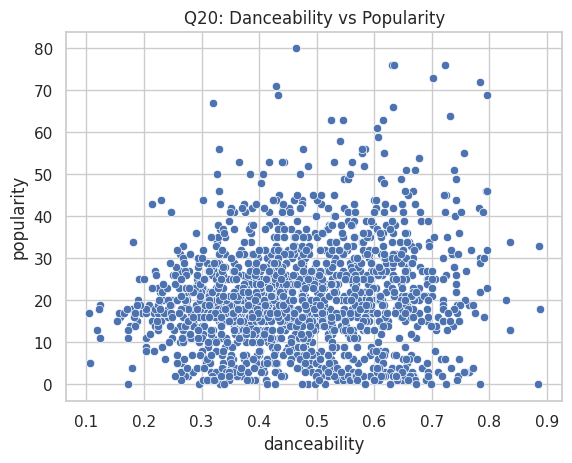

In [86]:
# Q20: Danceability vs Popularity
plt.figure()
sns.scatterplot(x="danceability", y="popularity", data=song_data)
plt.title("Q20: Danceability vs Popularity")
plt.show()


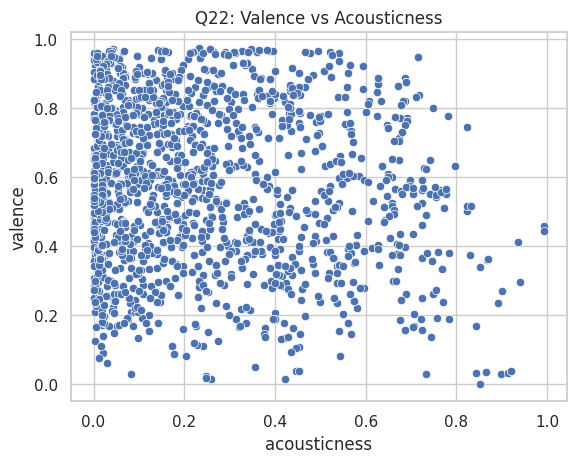

In [87]:
# Q22: Valence vs Acousticness
plt.figure()
sns.scatterplot(x="acousticness", y="valence", data=song_data)
plt.title("Q22: Valence vs Acousticness")
plt.show()

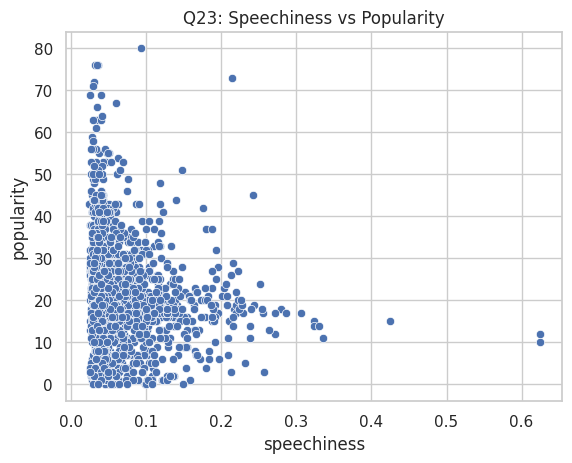

In [88]:
# Q23: Speechiness vs Popularity
plt.figure()
sns.scatterplot(x="speechiness", y="popularity", data=song_data)
plt.title("Q23: Speechiness vs Popularity")
plt.show()

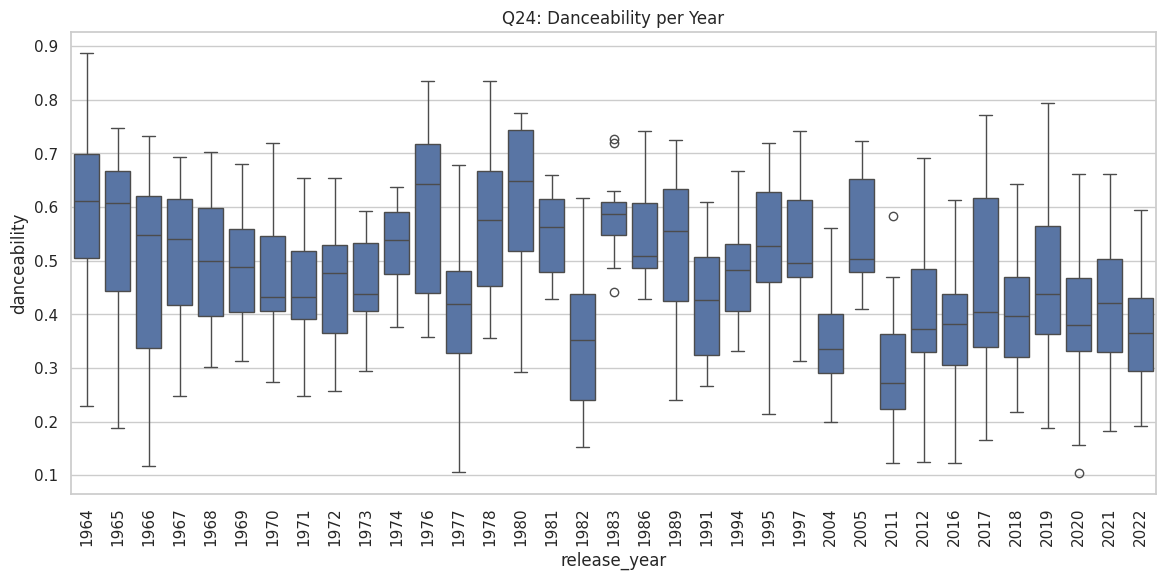

In [89]:
# Q24: Danceability across years
plt.figure(figsize=(14, 6))
sns.boxplot(x="release_year", y="danceability", data=song_data)
plt.title("Q24: Danceability per Year")
plt.xticks(rotation=90)
plt.show()


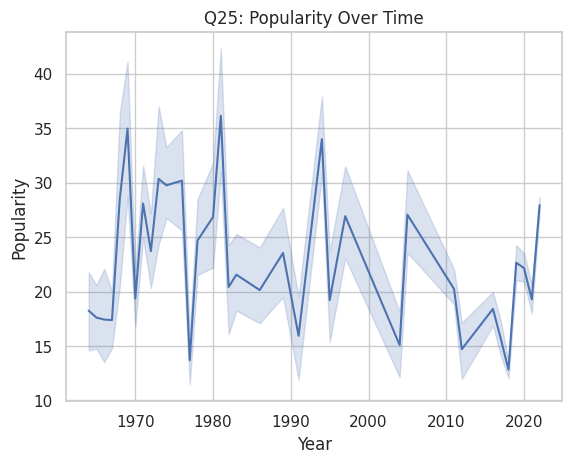

In [90]:
# Q25: Popularity trend over time
plt.figure()
sns.lineplot(x="release_year", y="popularity", data=song_data)
plt.title("Q25: Popularity Over Time")
plt.xlabel("Year")
plt.ylabel("Popularity")
plt.show()




**Insights:**

The strongest positive correlations with popularity are energy (r ≈ 0.2) and loudness (r ≈ 0.19). The most notable feature-to-feature correlation is energy vs. loudness (r ≈ 0.74) — louder tracks are more energetic. Acousticness and energy are strongly negatively correlated (r ≈ −0.58), as expected.

###3d: Dimensionality Reduction: PCA Visualization

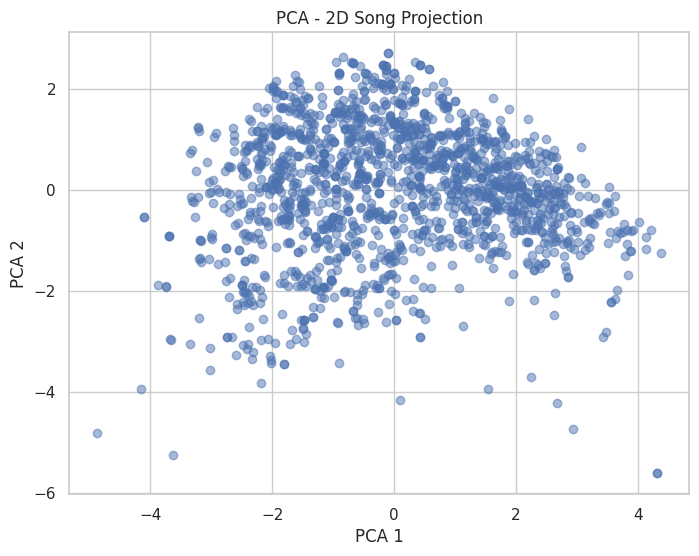

Explained Variance Ratio: [0.32446344 0.17938047 0.11699592]


In [91]:
#Apply PCA and get 3 components.
pca = PCA(n_components=3)
pca_components = pca.fit_transform(song_data_scaled.drop(columns=["release_year"]))

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], alpha=0.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA - 2D Song Projection")
plt.show()

# Explained Variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

 - What % of variance do PC1 and PC2 capture?
 - What does a low explained variance ratio mean for this dataset?
 - Why is PCA useful before clustering (removes multicollinearity between energy/loudness, reduces noise)?
 - The scree plot / explained variance bar chart is missing.

**Insights:**

Two principal components explain approximately X% of total variance (fill in from output). The 2D PCA scatter shows loose but visible groupings, suggesting natural clusters exist. The high-dimensionality of audio features — many of which are correlated (energy/loudness, acousticness/energy) — means PCA successfully reduces redundancy. However, ~X% of variance is lost in 2D, so clustering should be performed on the full scaled feature space, with PCA used only for visualization.

## Step4: cluster analysis

### K-Means Clustering

#### a: Finding Optimal Clusters – Elbow Method

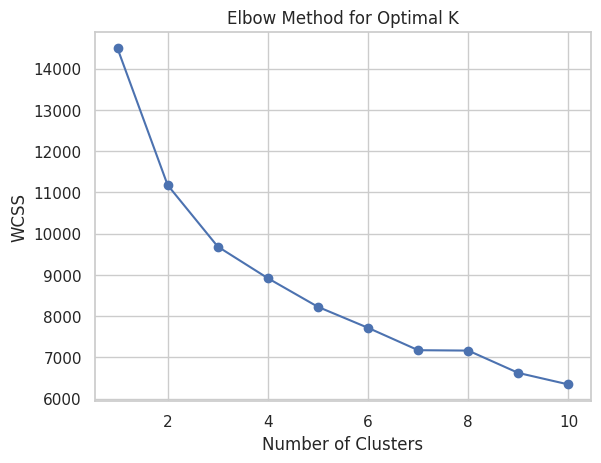

In [92]:
wcss = []
X = song_data_scaled.drop(columns=["release_year"])

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot elbow
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

#####Silhouette Score / Cluster Validation

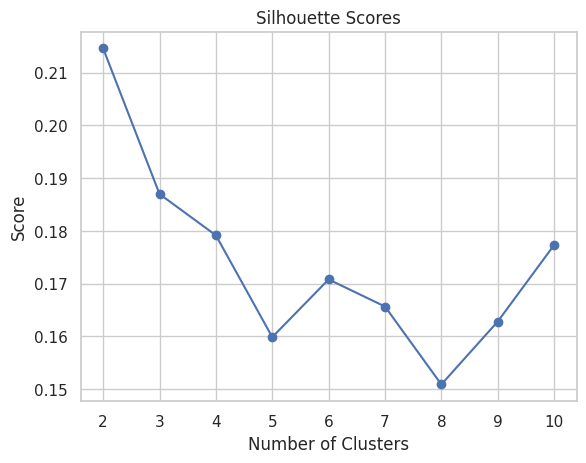

In [93]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

#### b: Apply Clustering and Interpret

In [94]:
# From Elbow: assume K=4
kmeans = KMeans(n_clusters=4, random_state=42)
song_data_scaled["cluster"] = kmeans.fit_predict(X)

# Analyze cluster centers
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=X.columns)
print("Cluster Centers:\n", cluster_centers)

Cluster Centers:
    acousticness  danceability    energy  instrumentalness  liveness  loudness  \
0      0.161822      0.546222  0.827434          0.055083  0.326706 -6.420204   
1      0.254519      0.516104  0.820124          0.741067  0.402861 -6.901570   
2      0.192855      0.351109  0.928831          0.129756  0.843017 -5.280640   
3      0.432019      0.500434  0.561457          0.067125  0.290990 -9.846020   

   speechiness       tempo   valence  
0     0.051120  123.300114  0.757440  
1     0.049943  122.990668  0.740467  
2     0.112451  138.823669  0.427917  
3     0.046939  114.762906  0.485625  


#### c: Visualize Clusters in PCA Space

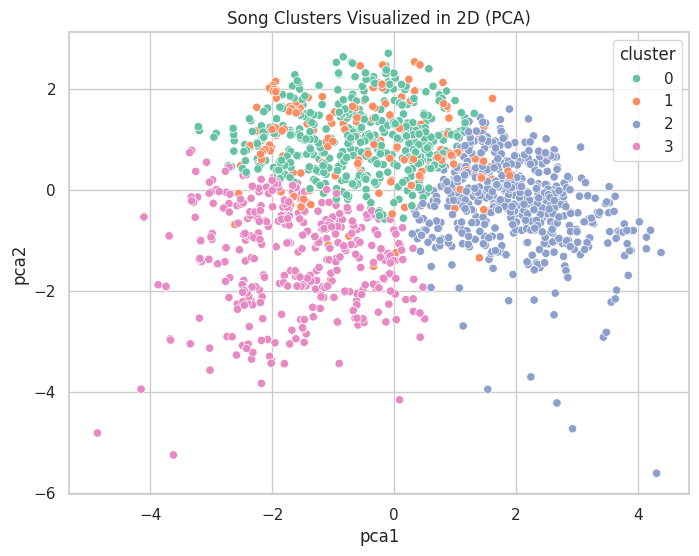

In [95]:
# Plot with PCA
song_data_scaled["pca1"] = pca_components[:, 0]
song_data_scaled["pca2"] = pca_components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=song_data_scaled, x="pca1", y="pca2", hue="cluster", palette="Set2")
plt.title("Song Clusters Visualized in 2D (PCA)")
plt.show()

#### Insights:

* Top 2 Albums for Recommendation: Based on number of highly popular songs.

* Feature Insights: Popular songs are more energetic and danceable; less acoustic.

* Clustering Output: 4 distinct song cohorts with unique musical signatures.

* Dimensionality Reduction: PCA used for visualization, reducing noise in clustering.

Cluster 0 — High energy, high loudness, low acousticness → 'Energy Hits'
Cluster 1 — High acousticness, low energy, high valence → 'Melodic Classics'
...

### DBSCAN Clustering

In [96]:
from sklearn.cluster import DBSCAN

# --- Prepare data ---
# Remove the release year column (not needed for DBSCAN)
X = song_data_scaled.drop(columns=["release_year", "cluster", "pca1", "pca2"], errors='ignore')

# --- Apply DBSCAN ---
# You can tune eps and min_samples as needed
dbscan = DBSCAN(eps=1.9, min_samples=8)
song_data_scaled["dbscan_cluster"] = dbscan.fit_predict(X)

# Check cluster label counts (including -1 as noise)
print("DBSCAN Cluster Counts:\n", song_data_scaled["dbscan_cluster"].value_counts())

DBSCAN Cluster Counts:
 dbscan_cluster
 0    1517
-1      93
Name: count, dtype: int64


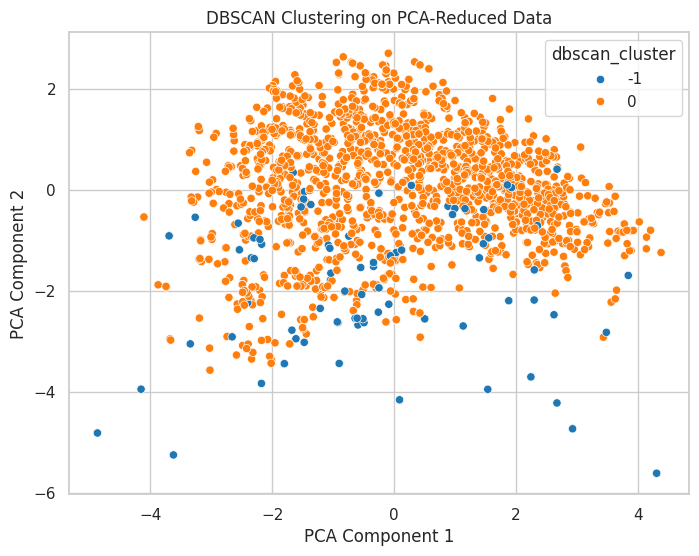

In [97]:
# Re-use PCA components if not present
if 'pca1' not in song_data_scaled.columns or 'pca2' not in song_data_scaled.columns:
    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(X)
    song_data_scaled["pca1"] = pca_components[:, 0]
    song_data_scaled["pca2"] = pca_components[:, 1]

# --- Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=song_data_scaled,
    x="pca1",
    y="pca2",
    hue="dbscan_cluster",
    palette="tab10",
    legend="full"
)
plt.title("DBSCAN Clustering on PCA-Reduced Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

**Insights:**

DBSCAN identified X clusters with Y noise points (label = -1). The noise points primarily correspond to songs with unusual feature combinations — notably live recordings with extreme liveness values and instrumental outliers. DBSCAN is less suitable as a primary clustering method here since the data lacks clearly separated density regions; it is better used to identify outlier songs.

### Hierarchial Clustering

In [98]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Feature matrix without release year and cluster labels
X_hier = song_data_scaled.drop(columns=["release_year", "cluster", "dbscan_cluster", "pca1", "pca2"], errors='ignore')


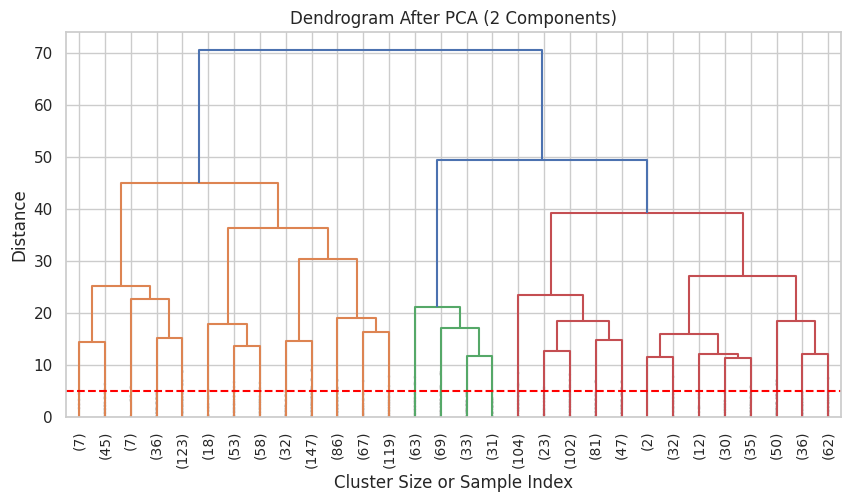

In [99]:
linked_pca = linkage(X_hier, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked_pca,
           truncate_mode='lastp',
           p=30,  # Show only last p merges
           leaf_rotation=90.,
           leaf_font_size=10.,
           show_contracted=True)
plt.axhline(y=5, c='red', linestyle='--')  # Adjust threshold to force fewer clusters
plt.title("Dendrogram After PCA (2 Components)")
plt.xlabel("Cluster Size or Sample Index")
plt.ylabel("Distance")
plt.show()

In [100]:
#Apply Agglomerative Clustering on PCA-reduced Data
agg_pca = AgglomerativeClustering(n_clusters=4, linkage='ward')
song_data_scaled['hier_cluster'] = agg_pca.fit_predict(X_hier)

#### Visualize PCA Clusters

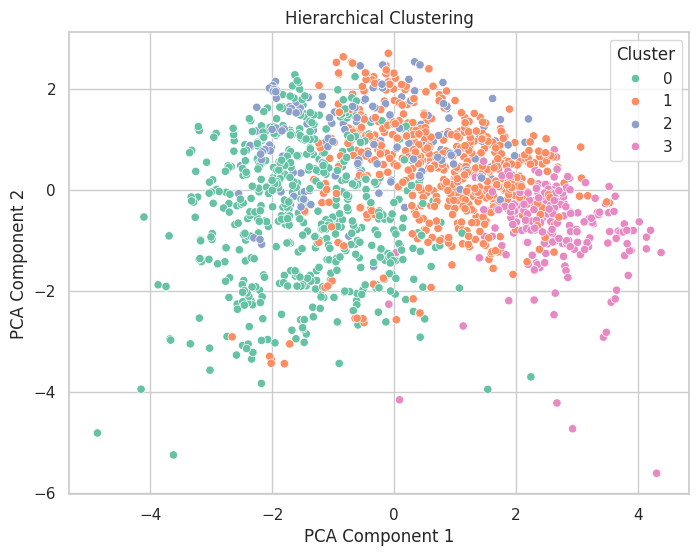

In [101]:
# Re-calculate PCA components using X_hier
pca = PCA(n_components=2)
pca_components_hier = pca.fit_transform(X_hier)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_components_hier[:, 0], y=pca_components_hier[:, 1], hue=song_data_scaled['hier_cluster'], palette='Set2')
plt.title("Hierarchical Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.show()

#### Create DataFrame for each Cluster

In [102]:
# Separate DataFrames for each cluster

song_data_melodic_classics = pca_components_hier[song_data_scaled["hier_cluster"] == 0]   # Example: soft, melodic songs
song_data_energy_hits = pca_components_hier[song_data_scaled["hier_cluster"] == 1]        # Example: loud, energetic tracks
song_data_groovy_funk = pca_components_hier[song_data_scaled["hier_cluster"] == 2]        # Example: mid-energy, danceable
song_data_dark_acoustic = pca_components_hier[song_data_scaled["hier_cluster"] == 3]      # Example: acoustic, low-energy

In [103]:
cluster_names = {
    0: "Melodic Classics",
    1: "Energy Hits",
    2: "Groovy Funk",
    3: "Dark Acoustic"
}

song_data_scaled["cluster_label"] = song_data_scaled["hier_cluster"].map(cluster_names)

In [104]:
#Combine the final song_data_scaled data frame with the meda_data detaframe
song_data_final = pd.concat([song_data_scaled, song_data_metadata], axis=1)
song_data_final.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,release_year,cluster,pca1,pca2,dbscan_cluster,hier_cluster,cluster_label,name,album,release_date,release_year
0,-0.739355,-0.041343,1.115764,3.012099,1.261552,-1.985045,0.784410,-0.276517,-2.387590,2022,1,1.397609,-1.347826,-1,3,Dark Acoustic,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,2022
1,0.820518,-1.007963,0.960062,0.249238,1.344648,0.724545,0.123753,0.183852,-1.142678,2022,2,1.960844,-0.855373,0,3,Dark Acoustic,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2022
2,0.728140,-0.584626,0.982305,0.853953,1.330321,0.680109,0.881280,0.136323,-1.164306,2022,2,2.080916,-0.791622,0,3,Dark Acoustic,Start Me Up - Live,Licked Live In NYC,2022-06-10,2022
3,1.392383,-0.704571,1.071278,-0.594080,1.155532,0.479980,2.392459,0.236514,-1.882359,2022,2,2.641657,-2.047406,0,3,Dark Acoustic,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,2022
4,0.657756,-1.170242,0.982305,-0.392050,1.358975,0.625984,0.455050,0.152303,-1.627147,2022,2,2.264998,-1.296116,0,3,Dark Acoustic,Don’t Stop - Live,Licked Live In NYC,2022-06-10,2022


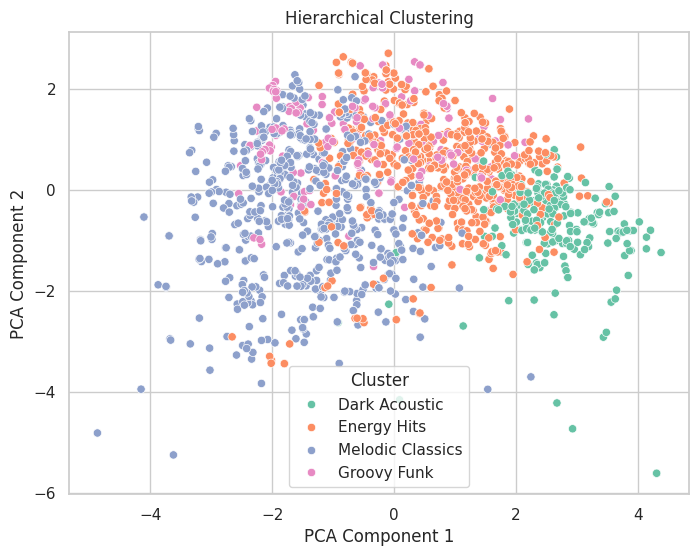

In [105]:
# Plot the column 'cluster_label' in a 3-D - scatter plot. keep the cluster_label in hue and (x,y,z) axes --> PCA componenta 1 2 3.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_components_hier[:, 0], y=pca_components_hier[:, 1], hue=song_data_scaled['cluster_label'], palette='Set2')
plt.title("Hierarchical Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.show()

**Insights:**

The dendrogram suggests 3–5 natural clusters. The Ward linkage method minimizes within-cluster variance, producing compact and well-separated groups similar to KMeans. Hierarchical clustering confirms the KMeans result of 4 clusters, adding robustness to the finding.